In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("data/superstore_sales.xlsx",engine="openpyxl")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66.120,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",44.865,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",113.670,5,0.1,37.770,4.70,Medium,2011


In [2]:
df.shape

(51290, 21)

In [3]:
df.columns

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  str           
 1   order_date      51290 non-null  datetime64[us]
 2   ship_date       51290 non-null  datetime64[us]
 3   ship_mode       51290 non-null  str           
 4   customer_name   51290 non-null  str           
 5   segment         51290 non-null  str           
 6   state           51290 non-null  str           
 7   country         51290 non-null  str           
 8   market          51290 non-null  str           
 9   region          51290 non-null  str           
 10  product_id      51290 non-null  str           
 11  category        51290 non-null  str           
 12  sub_category    51290 non-null  str           
 13  product_name    51290 non-null  str           
 14  sales           51290 non-null  float64       
 15  quantity     

In [5]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit,shipping_cost,year
count,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,2013-05-11 21:26:49.155780,2013-05-15 20:42:42.745174,246.490581,3.476545,0.142908,28.641740,26.375818,2012.777208
min,2011-01-01 00:00:00,2011-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0.002000,2011.000000
25%,2012-06-19 00:00:00,2012-06-23 00:00:00,30.758625,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,2013-07-08 00:00:00,2013-07-12 00:00:00,85.053000,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,2014-05-22 00:00:00,2014-05-26 00:00:00,251.053200,5.000000,0.200000,36.810000,24.450000,2014.000000
max,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.480000,14.000000,0.850000,8399.976000,933.570000,2014.000000
std,NaN,NaN,487.565361,2.278766,0.212280,174.424113,57.296810,1.098931


In [6]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.groupby('category')['sales'].sum().sort_values(ascending=False)

category
Technology         4.744557e+06
Furniture          4.110874e+06
Office Supplies    3.787070e+06
Name: sales, dtype: float64

In [9]:
cat_analysis = df.groupby('category')[['sales','profit']].sum().reset_index()
cat_analysis

,category,sales,profit
0,Furniture,4.110874e+06,286782.25380
1,Office Supplies,3.787070e+06,518473.83430
2,Technology,4.744557e+06,663778.73318


C:\Users\VIDYA COMOUTERS\AppData\Local\Temp\ipykernel_6912\3368933258.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category',y='profit',data=cat_analysis,palette='coolwarm')


<function matplotlib.pyplot.show(close=None, block=None)>

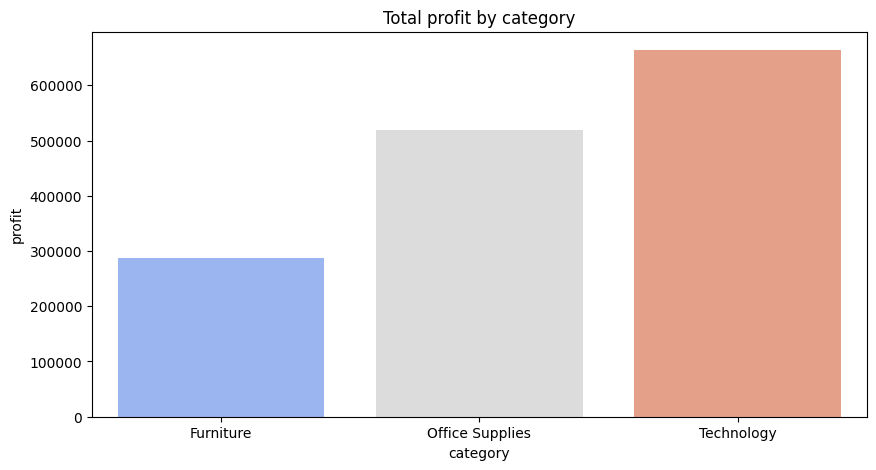

In [10]:

plt.figure(figsize=(10,5))
sns.barplot(x='category',y='profit',data=cat_analysis,palette='coolwarm')
plt.title('Total profit by category')
plt.show

# Key Insights: Total Profit by Category

1. Highest Profit Leader: The Technology category generates the highest profit for the business, reaching over 600,000. This indicates that high-ticket tech products are the primary driver of profitability.

2. Steady Performer: Office Supplies is the second most profitable segment, bringing in around 500,000. This category suggests consistent demand and a reliable revenue stream.

3. Lowest Profit Margin: Furniture* brings in the lowest profit, sitting below 300,000. This lower margin could be due to high shipping fees, heavy discounting, or higher material costs.

# Business Strategy and Recommendations

1. Maximize Tech Marketing: Allocate a larger portion of the marketing and advertising budget to Technology products since they yield the highest return on investment.

2. Optimize Furniture Margins: Conduct a detailed review of the **Furniture* category pricing, logistical expenses, and discount strategies to identify where profit is being lost and find ways to improve efficiency.


In [16]:
loss_product = df.groupby('product_name')['profit'].sum().sort_values().head(10).reset_index()
loss_product

,product_name,profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,"Motorola Smart Phone, Cordless",-4447.0380
3,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
4,"Bevis Round Table, Adjustable Height",-3649.8940
5,"Bevis Computer Table, Fully Assembled",-3509.5638
6,"Rogers Lockers, Blue",-2893.4908
7,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
8,"Bevis Wood Table, with Bottom Storage",-2782.5880
9,"Lesro Training Table, Rectangular",-2581.2834


C:\Users\VIDYA COMOUTERS\AppData\Local\Temp\ipykernel_6912\4061837935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='product_name',x='profit',data=loss_product,palette='Reds_r')


<function matplotlib.pyplot.show(close=None, block=None)>

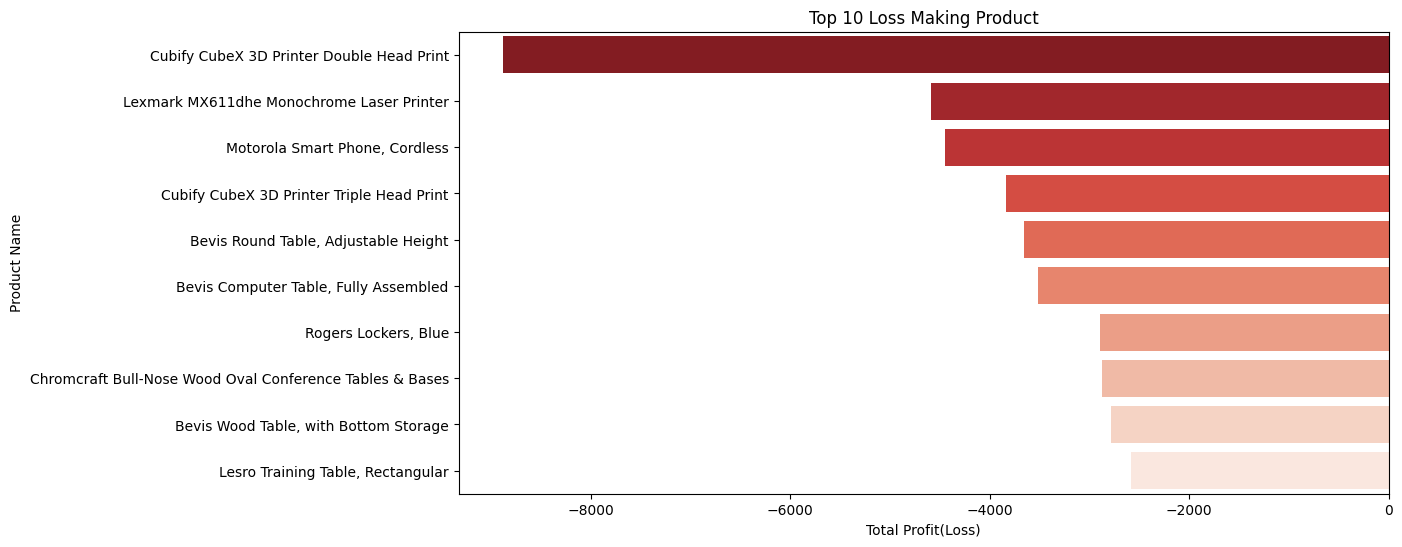

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(y='product_name',x='profit',data=loss_product,palette='Reds_r')
plt.title('Top 10 Loss Making Product')
plt.xlabel('Total Profit(Loss)')
plt.ylabel('Product Name')
plt.show

# Key Insights: Top 10 Loss Making Products

1. Highest Loss Contributor: The Cubify CubeX 3D Printer Double Head Print* is the most significant loss-making item, causing a negative profit of over 8,000. This requires immediate attention as it significantly drains the company's overall net profit.

2. High-Value Product Issues: Other premium technology products, specifically the Lexmark MX611dhe Monochrome Laser Printer* and the Motorola Smart Phone, Cordless, are also among the top three biggest loss-makers. This indicates that major hardware items are suffering from serious profitability issues.

3. Furniture Segment Concerns: Multiple furniture items, such as the Bevis Round Table, Bevis Computer Table, and **Chromcraft Wood Oval Conference Tables, appear frequently on this list. This supports our previous finding that the Furniture category as a whole struggles with low profit margins.

# Business Strategy and Recommendations

1. Investigate Pricing and Shipping Cost: Conduct an urgent review of the pricing structure, shipping fees, and vendor costs for the top loss-makers, especially the Cubify 3D Printers. High logistics or return rates for heavy electronic and furniture items might be destroying the margins.

2. Re-evaluate Discounting Models: Analyze if these products are frequently sold under heavy promotional discounts. If aggressive promotional pricing is driving these losses, consider implementing a minimum price threshold or reducing maximum allowable discount percentages.

3. Discontinue or renegotiate: If the acquisition cost from suppliers remains too high to turn a profit, consider stopping the sale of these specific high-loss items or renegotiating contract terms with the manufacturers.


<function matplotlib.pyplot.show(close=None, block=None)>

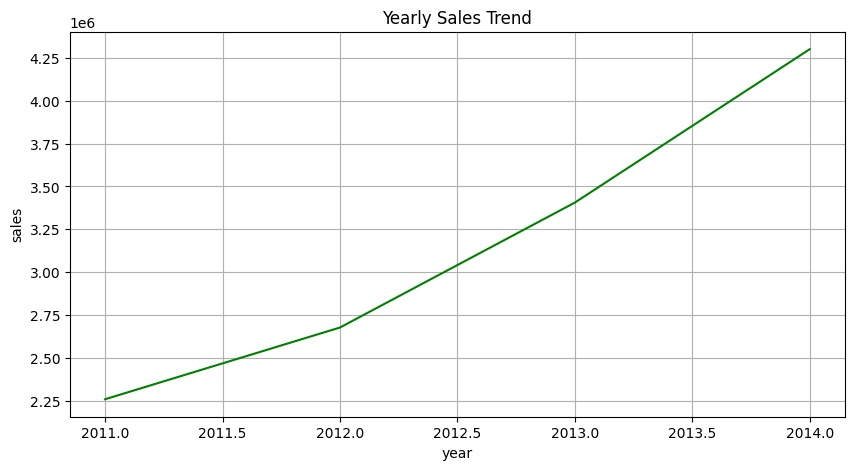

In [21]:
yearly_sales =df.groupby('year')['sales'].sum().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(x='year',y='sales',data=yearly_sales,markers='o',color='green')
plt.title('Yearly Sales Trend')
plt.grid(True)
plt.show

# Key Insights: Top 10 Loss Making Products

1. Highest Loss Contributor: The Cubify CubeX 3D Printer Double Head Print* is the most significant loss-making item, causing a negative profit of over 8,000. This requires immediate attention as it significantly drains the company's overall net profit.

2. High-Value Product Issues: Other premium technology products, specifically the Lexmark MX611dhe Monochrome Laser Printer and the Motorola Smart Phone, Cordless, are also among the top three biggest loss-makers. This indicates that major hardware items are suffering from serious profitability issues.

3. Furniture Segment Concerns: Multiple furniture items, such as the Bevis Round Table, Bevis Computer Table, and Chromcraft Wood Oval Conference Tables, appear frequently on this list. This supports our previous finding that the Furniture category as a whole struggles with low profit margins.

# Business Strategy and Recommendations

1. Investigate Pricing and Shipping Cost: Conduct an urgent review of the pricing structure, shipping fees, and vendor costs for the top loss-makers, especially the Cubify 3D Printers. High logistics or return rates for heavy electronic and furniture items might be destroying the margins.

2. Re-evaluate Discounting Models: Analyze if these products are frequently sold under heavy promotional discounts. If aggressive promotional pricing is driving these losses, consider implementing a minimum price threshold or reducing maximum allowable discount percentages.

3. Discontinue or renegotiate: If the acquisition cost from suppliers remains too high to turn a profit, consider stopping the sale of these specific high-loss items or renegotiating contract terms with the manufacturers.
4.

<function matplotlib.pyplot.show(close=None, block=None)>

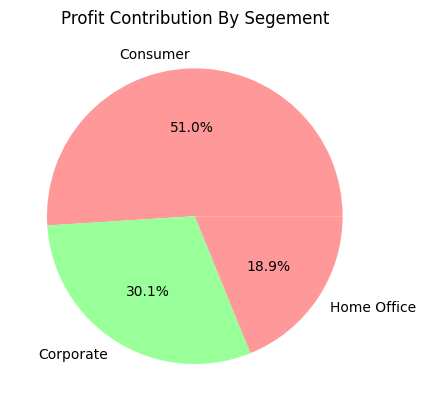

In [22]:
segement_analysis = df.groupby('segment')['profit'].sum().reset_index()
plt.Figure(figsize=(8,5))
plt.pie(segement_analysis['profit'],labels=segement_analysis['segment'],autopct='%1.1f%%',colors=['#ff9999','#99ff99'])
plt.title('Profit Contribution By Segement')
plt.show

# Key Insights: Profit Contribution By Segment

1. Dominant Market Segment: The Consumer segment is the absolute powerhouse of the business, contributing more than half of the total profits at 51.0%. This indicates that the primary customer base consists of individual buyers, making them the most vital audience for overall business profitability.

2. Strong B2B Presence: The Corporate segment is the second-largest profit contributor, bringing in 30.1% of the total profit. This shows a very healthy and stable business-to-business (B2B) revenue stream alongside the individual consumers.

3. Niche Performer: The Home Office segment contributes the remaining 18.9% of the profit. While it is the smallest segment, it still represents a substantial, nearly one-fifth portion of total profitability that should not be overlooked.

# Business Strategy and Recommendations

1. Strengthen Consumer Retention: Since the Consumer segment drives the majority of profits, design dedicated loyalty programs, personalized email marketing campaigns, and exclusive product bundles to maximize the customer lifetime value of these buyers.

2. Expand Corporate Partnerships: With a solid 30.1% profit contribution, the Corporate segment shows high potential. Consider introducing bulk-purchase discounts, dedicated account managers, or post-purchase business services to attract more large-scale corporate clients and increase order values.

3. Targeted Campaigns for Home Office: Tailor marketing campaigns specifically aimed at remote workers and freelancer demographics to boost the Home Office segment share, as this market segment has grown rapidly due to remote-work trends.

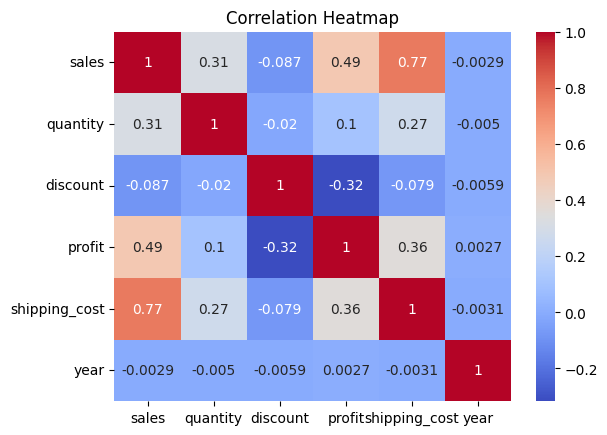

In [23]:
plt.Figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['Float64','int64']).corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Key Insights: Correlation Heatmap Analysis

1. Strong Positive Relationship between Sales and Shipping Cost: There is a very strong positive correlation of 0.77 between sales and shipping_cost. This clearly indicates that as the order value or transaction size increases, the logistical and shipping expenses scale up significantly alongside it.

2. Moderate Positive Relationship between Sales and Profit: The correlation between sales and profit stands at a moderate 0.49. This implies that while higher sales generally yield higher profits, it is not a perfect 1:1 relationship. Other factors, like overhead and specific product costs, still play a substantial role.

3. Negative Impact of Discounts on Profit: The correlation between discount and profit is negative at -0.32. This confirms that offering higher discounts is statistically linked to reduced profitability, validating our earlier findings about certain highly discounted products generating net losses.

4. Weak Relationship with Year: The variable year shows almost zero correlation (close to 0.00) across all other business metrics, including sales and profit. This suggests that the time factor itself does not inherently change the transactional behavior or profit margins; rather, tactical changes like pricing or volume drive the numbers.

# Business Strategy and Recommendations

1. Optimize Shipping Strategy: Since shipping costs scale steeply with sales (0.77), the company should renegotiate contracts with shipping partners or optimize warehouse distribution centers to lower per-unit logistics expenses for high-value orders.

2. Re-evaluate Discounting Thresholds: Given the negative impact of discounts on profits (-0.32), the marketing team should move away from flat site-wide discounts. Instead, transition to target-based promotions (e.g., "Buy 2 Get 1 Free" or loyalty rewards) that maintain healthier profit margins.

3. Focus on High-Margin Sales Volume*: Since sales volume does not guarantee equal profit growth (0.49), business efforts should focus on prioritizing higher-margin categories (like Technology) rather than blindly pushing for overall top-line sales growth in lower-margin segments.